##MDP Fundamentals

In [53]:
import numpy as np
import matplotlib.pyplot as plt

In [54]:
class S:
    def __init__(self, name, terminal=False):
        self.name = name
        self.terminal = terminal

    def __repr__(self):
        return self.name


In [55]:
class MDP:
    def __init__(self):
        # Define States
        self.states = [
            S("s0"),
            S("s1"),
            S("s2"),
            S("s3", terminal=True)
        ]

        # Define Actions
        self.actions = ["a0", "a1"]

        self.n_states = len(self.states)
        self.n_actions = len(self.actions)

        # Transition Probabilities
        # Shape = (actions, states, next_states)
        self.P = np.zeros((self.n_actions, self.n_states, self.n_states))

        # ---------- Action a0 ----------
        self.P[0, 0] = [0.0, 1.0, 0.0, 0.0]      # s0 -> s1
        self.P[0, 1] = [0.0, 0.2, 0.8, 0.0]      # s1 -> stochastic
        self.P[0, 2] = [0.0, 0.0, 0.0, 1.0]      # s2 -> s3
        self.P[0, 3] = [0.0, 0.0, 0.0, 1.0]      # terminal stays

        # ---------- Action a1 ----------
        self.P[1, 0] = [0.0, 0.0, 1.0, 0.0]      # s0 -> s2
        self.P[1, 1] = [1.0, 0.0, 0.0, 0.0]      # s1 -> s0
        self.P[1, 2] = [0.0, 1.0, 0.0, 0.0]      # s2 -> s1
        self.P[1, 3] = [0.0, 0.0, 0.0, 1.0]      # terminal stays

        # Reward Matrix R(s,a)
        # Rows = states, Columns = actions
        self.R = np.array([
            [-1, -2],   # s0
            [ 5, -1],   # s1
            [10,  0],   # s2
            [ 0,  0]    # s3 (terminal)
        ])

    def print_transition_matrices(self):
        for a_idx, action in enumerate(self.actions):
            print(f"\nTransition Matrix for Action {action}")
            print("-" * 40)
            print(self.P[a_idx])

    def print_reward_matrix(self):
        print("\nReward Matrix R(s,a)")
        print("-" * 40)
        print("Rows    : States (s0,s1,s2,s3)")
        print("Columns : Actions (a0,a1)")
        print(self.R)

    def describe(self):
        print("\nEnvironment Description")
        print("-" * 40)
        print("States:")
        for s in self.states:
            if s.terminal:
                print(f"  {s} (Terminal)")
            else:
                print(f"  {s}")

        print("\nActions:")
        print("  a0")
        print("  a1")

        print("\nCharacteristics:")
        print("- Episodic MDP")
        print("- Terminal state: s3")
        print("- Stochastic transition:")
        print("    P(s2 | s1, a0) = 0.8")
        print("    P(s1 | s1, a0) = 0.2")
        print("- All transitions from s3 remain in s3.")



In [56]:
if __name__ == "__main__":
    mdp = MDP()

    mdp.describe()
    mdp.print_transition_matrices()
    mdp.print_reward_matrix()


Environment Description
----------------------------------------
States:
  s0
  s1
  s2
  s3 (Terminal)

Actions:
  a0
  a1

Characteristics:
- Episodic MDP
- Terminal state: s3
- Stochastic transition:
    P(s2 | s1, a0) = 0.8
    P(s1 | s1, a0) = 0.2
- All transitions from s3 remain in s3.

Transition Matrix for Action a0
----------------------------------------
[[0.  1.  0.  0. ]
 [0.  0.2 0.8 0. ]
 [0.  0.  0.  1. ]
 [0.  0.  0.  1. ]]

Transition Matrix for Action a1
----------------------------------------
[[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]

Reward Matrix R(s,a)
----------------------------------------
Rows    : States (s0,s1,s2,s3)
Columns : Actions (a0,a1)
[[-1 -2]
 [ 5 -1]
 [10  0]
 [ 0  0]]


##Exploring nx module

In [57]:
import networkx as nx

In [58]:
G = nx.petersen_graph()

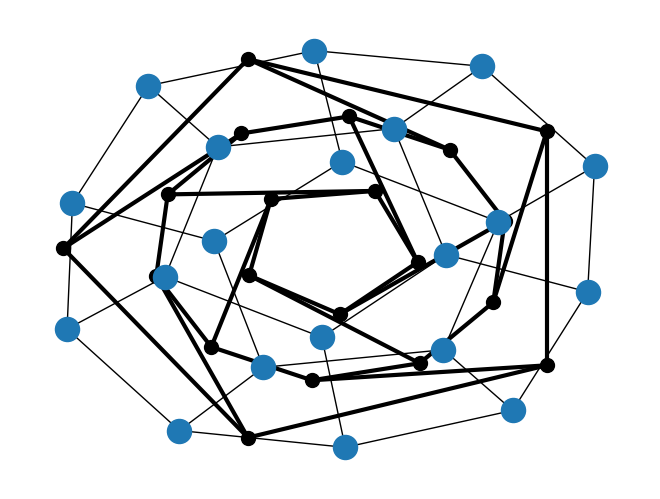

In [59]:
G = nx.dodecahedral_graph()
options = {
    'node_color': 'black',
    'node_size': 100,
    'width': 3,
}
shells = [[2, 3, 4, 5, 6], [8, 1, 0, 19, 18, 17, 16, 15, 14, 7], [9, 10, 11, 12, 13]]
nx.draw_shell(G, nlist=shells, **options)
nx.draw(G)

##Visualizing the MDP

In [60]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [61]:
def visualize(mdp):
    G = nx.MultiDiGraph()   # Allows multiple edges between same nodes

    # Add states as nodes
    for state in mdp.states:
        G.add_node(state.name)

    # Add transitions as edges
    for a_idx, action in enumerate(mdp.actions):
        for s in range(mdp.n_states):
            for sp in range(mdp.n_states):

                prob = mdp.P[a_idx, s, sp]

                if prob > 0:
                    reward = mdp.R[s, a_idx]

                    G.add_edge(
                        mdp.states[s].name,
                        mdp.states[sp].name,
                        action=action,
                        probability=prob,
                        reward=reward
                    )

    # Layout manual
    # pos = {
    #     "s0": (0, 0),
    #     "s1": (1, 1),
    #     "s2": (1, -1),
    #     "s3": (2, 0)
    # }
    

    # Layout using Module NetworkX
    pos = nx.kamada_kawai_layout(G)
    # pos = nx.shell_layout(G)
    # pos = nx.spectral_layout(G)
    # pos = nx.planar_layout(G)
    # pos = nx.circular_layout(G)
    # pos = nx.random_layout(G) #only for debugging
    # pos = graphviz_layout(G, prog="dot") #needs additional module avoid for small assignment

    plt.figure(figsize=(10,6))

    # Node colors
    node_colors = [
        "lightgreen" if state.terminal else "skyblue"
        for state in mdp.states
    ]

    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=1800
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=12,
        font_weight="bold"
    )

    # Separate edges by action
    a0_edges = []
    a1_edges = []


    for u, v, key, data in G.edges(keys=True, data=True):
        if data["action"] == "a0":
            a0_edges.append((u, v, key))
        else:
            a1_edges.append((u, v, key))
    # Draw edges
    # nx.draw_networkx_edges(
    #     G,
    #     pos,
    #     arrows=True,
    #     arrowstyle='-|>',
    #     arrowsize=20,
    #     connectionstyle="arc3,rad=0.15"
    # )
    # Draw a0 edges
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=a0_edges,
        edge_color="blue",
        arrows=True,
        arrowstyle='-|>',
        arrowsize=20,
        width=2,
        connectionstyle="arc3,rad=0.15"
    )


    # Draw a1 edges
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=a1_edges,
        edge_color="darkred",
        style="dashed",
        arrows=True,
        arrowstyle='-|>',
        arrowsize=20,
        width=2,
        connectionstyle="arc3,rad=-0.15"
    )

    
    # Edge labels
    edge_labels = {}
    a0_labels = {}
    a1_labels = {}
    for u, v, key, data in G.edges(keys=True, data=True):
        
            label = f"P={data['probability']:.1f}\nR={data['reward']}"
        
            if data["action"] == "a0":
                a0_labels[(u, v, key)] = label
            else:
                a1_labels[(u, v, key)] = label
    

    # for u, v, key, data in G.edges(keys=True, data=True):
    #     edge_labels[(u, v, key)] = (
    #         f"{data['action']}\n"
    #         f"P={data['probability']:.1f}\n"
    #         f"R={data['reward']}"
    #     )

    # nx.draw_networkx_edge_labels(
    #     G,
    #     pos,
    #     edge_labels=edge_labels,
    #     font_size=8
    # )
    nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=a0_labels,
    font_color="blue",
    font_size=8,
    rotate=False
)

    nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=a1_labels,
    font_color="darkred",
    font_size=8,
    rotate=False
    )

    # Legend
    legend_elements = [

        # Node legends
        Patch(
            facecolor="skyblue",
            edgecolor="black",
            label="Normal State"
        ),

        Patch(
            facecolor="lightgreen",
            edgecolor="black",
            label="Terminal State"
        ),

        # Action legends
        Line2D(
            [0],
            [0],
            color="blue",
            lw=2,
            label="Action a0"
        ),

        Line2D(
            [0],
            [0],
            color="darkred",
            lw=2,
            linestyle="--",
            label="Action a1"
        )
    ]

    plt.legend(
        handles=legend_elements,
        title="MDP Legend",
        loc="upper left",
        fontsize=9
    )

    
    plt.title("4-State Episodic MDP")
    plt.axis("off")
    plt.show()


Environment Description
----------------------------------------
States:
  s0
  s1
  s2
  s3 (Terminal)

Actions:
  a0
  a1

Characteristics:
- Episodic MDP
- Terminal state: s3
- Stochastic transition:
    P(s2 | s1, a0) = 0.8
    P(s1 | s1, a0) = 0.2
- All transitions from s3 remain in s3.

Transition Matrix for Action a0
----------------------------------------
[[0.  1.  0.  0. ]
 [0.  0.2 0.8 0. ]
 [0.  0.  0.  1. ]
 [0.  0.  0.  1. ]]

Transition Matrix for Action a1
----------------------------------------
[[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]

Reward Matrix R(s,a)
----------------------------------------
Rows    : States (s0,s1,s2,s3)
Columns : Actions (a0,a1)
[[-1 -2]
 [ 5 -1]
 [10  0]
 [ 0  0]]


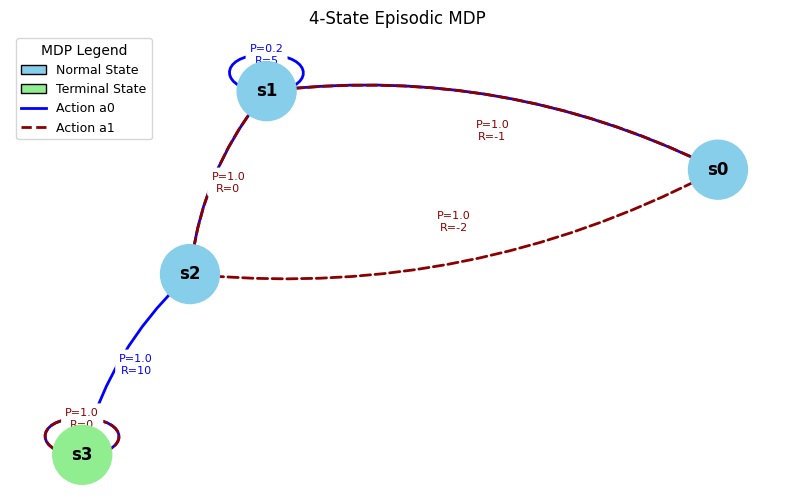

In [62]:
mdp = MDP()

mdp.describe()
mdp.print_transition_matrices()
mdp.print_reward_matrix()

visualize(mdp)

##Simulating Episodes

In [63]:
def random_policy(mdp, state):
    return np.random.choice(mdp.n_actions)

In [64]:

def simulate_episode(mdp, max_length=10):
    
    trajectory = []
    total_return = 0

    # Start from s0
    current_state = 0

    for step in range(max_length):

        # Stop if terminal state reached
        if mdp.states[current_state].terminal:
            print("Reached terminal state:",mdp.states[current_state].name)
            break

        # Random policy: choose action randomly
        # action_idx = np.random.choice(mdp.n_actions)
        action_idx = random_policy(mdp, current_state)
        action = mdp.actions[action_idx]

        # Get reward R(s,a)
        reward = int(mdp.R[current_state, action_idx])

        # Store (state, action, reward)
        trajectory.append(
            (
                mdp.states[current_state].name,
                action,
                reward
            )
        )

        total_return += reward

        # Sample next state using transition probabilities
        next_state = np.random.choice(
            mdp.n_states,
            p=mdp.P[action_idx, current_state]
        )

        current_state = next_state


    return trajectory, total_return

In [65]:
def simulate_episodes(mdp, num_episodes=10, max_length=10):

    returns = []

    for episode in range(num_episodes):

        trajectory, total_return = simulate_episode(
            mdp,
            max_length
        )

        returns.append(total_return)

        print(f"\nEpisode {episode+1}")
        print("-"*30)

        for step in trajectory:
            print(step)

        print("Return =", total_return)


    average_return = np.mean(returns)

    print("\n==============================")
    print("Average Return over episodes:", average_return)
    print("==============================")


    return returns

In [66]:
mdp = MDP()

returns = simulate_episodes(
    mdp,
    num_episodes=10,
    max_length=10
)

Reached terminal state: s3

Episode 1
------------------------------
('s0', 'a1', -2)
('s2', 'a0', 10)
Return = 8
Reached terminal state: s3

Episode 2
------------------------------
('s0', 'a0', -1)
('s1', 'a0', 5)
('s2', 'a0', 10)
Return = 14
Reached terminal state: s3

Episode 3
------------------------------
('s0', 'a1', -2)
('s2', 'a1', 0)
('s1', 'a1', -1)
('s0', 'a1', -2)
('s2', 'a0', 10)
Return = 5
Reached terminal state: s3

Episode 4
------------------------------
('s0', 'a1', -2)
('s2', 'a1', 0)
('s1', 'a1', -1)
('s0', 'a1', -2)
('s2', 'a1', 0)
('s1', 'a0', 5)
('s2', 'a0', 10)
Return = 10
Reached terminal state: s3

Episode 5
------------------------------
('s0', 'a0', -1)
('s1', 'a0', 5)
('s2', 'a0', 10)
Return = 14
Reached terminal state: s3

Episode 6
------------------------------
('s0', 'a1', -2)
('s2', 'a1', 0)
('s1', 'a0', 5)
('s2', 'a0', 10)
Return = 13
Reached terminal state: s3

Episode 7
------------------------------
('s0', 'a1', -2)
('s2', 'a0', 10)
Return = 8
Re

##Bellman equation
(Recursive nature)
v_pi = R_pi + (\gamma)*q_pi 
or 
v_pi = (I - \gamma P^pi)^-1 * R_pi

it is *expectation* over :
    - action selected by policy
    - next state reached after taking action

##Polict Evaluation

In [67]:
def iterative_policy_evaluation(mdp, gamma=0.9, theta=0.001):

    # Initialize value function
    V = np.zeros(mdp.n_states)

    iteration = 0
    history = []

    while True:

        delta = 0
        new_V = V.copy()

        for s in range(mdp.n_states):

            # Terminal state's value remains zero
            if mdp.states[s].terminal:
                continue

            value = 0

            # Random policy
            for a in range(mdp.n_actions):

                action_prob = 1 / mdp.n_actions

                expected_next = 0

                for sp in range(mdp.n_states):

                    transition_prob = mdp.P[a, s, sp]

                    expected_next += transition_prob * (
                        mdp.R[s, a] + gamma * V[sp]
                    )

                value += action_prob * expected_next

            new_V[s] = value

            delta = max(delta, abs(new_V[s] - V[s]))

        V = new_V
        history.append(V.copy())

        iteration += 1

        if delta < theta:
            break

    return V, history

In [68]:
def print_value_iterations(history):

    print(f"{'Iter':<6}{'V(s0)':>12}{'V(s1)':>12}{'V(s2)':>12}{'V(s3)':>12}")

    print("-"*54)

    for i, values in enumerate(history):

        print(
            f"{i+1:<6}"
            f"{values[0]:>12.3f}"
            f"{values[1]:>12.3f}"
            f"{values[2]:>12.3f}"
            f"{values[3]:>12.3f}"
        )

In [69]:
V, history = iterative_policy_evaluation(mdp)

print_value_iterations(history)

print("\nFinal Value Function")

for i, value in enumerate(V):
    print(f"{mdp.states[i].name}: {value:.3f}")

Iter         V(s0)       V(s1)       V(s2)       V(s3)
------------------------------------------------------
1           -1.500       2.000       5.000       0.000
2            1.650       3.305       5.900       0.000
3            2.642       5.164       6.487       0.000
4            3.743       5.989       7.324       0.000
5            4.491       6.860       7.695       0.000
6            5.050       7.409       8.087       0.000
7            5.473       7.850       8.334       0.000
8            5.783       8.170       8.533       0.000
9            6.016       8.409       8.676       0.000
10           6.189       8.588       8.784       0.000
11           6.317       8.720       8.864       0.000
12           6.413       8.819       8.924       0.000
13           6.484       8.892       8.968       0.000
14           6.537       8.947       9.001       0.000
15           6.577       8.988       9.026       0.000
16           6.606       9.018       9.044       0.000
17        

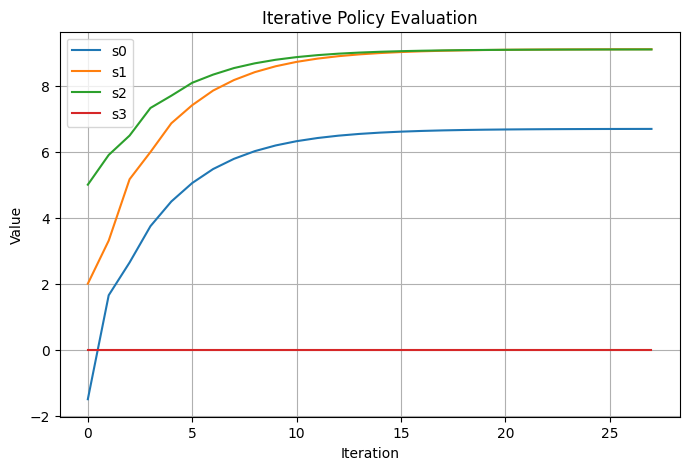

In [70]:
history = np.array(history)

plt.figure(figsize=(8,5))

for s in range(mdp.n_states):
    plt.plot(history[:, s], label=mdp.states[s].name)

plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Iterative Policy Evaluation")
plt.legend()
plt.grid(True)

##Policy iteration

In [71]:
policy = np.random.randint(0, mdp.n_actions, size=mdp.n_states)

In [72]:
def policy_evaluation(mdp, policy, gamma=0.9, theta=0.001):

    V = np.zeros(mdp.n_states)

    while True:

        delta = 0

        for s in range(mdp.n_states):

            if mdp.states[s].terminal:
                continue

            old_v = V[s]

            action = policy[s]

            V[s] = 0

            for sp in range(mdp.n_states):

                V[s] += mdp.P[action, s, sp] * (
                    mdp.R[s, action] + gamma * V[sp]
                )

            delta = max(delta, abs(old_v - V[s]))

        if delta < theta:
            break

    return V

In [73]:
def policy_improvement(mdp, V, gamma=0.9):

    policy_stable = True #why used this ?

    new_policy = np.zeros(mdp.n_states, dtype=int)

    for s in range(mdp.n_states):

        if mdp.states[s].terminal:
            continue

        action_values = []

        for a in range(mdp.n_actions):

            q = 0

            for sp in range(mdp.n_states):

                q += mdp.P[a, s, sp] * (
                    mdp.R[s, a] + gamma * V[sp]  
                )

            action_values.append(q)

        new_policy[s] = np.argmax(action_values)

    return new_policy

In [74]:
def policy_iteration(mdp, gamma=0.9, theta=0.001):

    policy = np.random.randint(
        0,
        mdp.n_actions,
        size=mdp.n_states
    )

    iteration = 1
    policy_history = []
    value_history = []

    while True:

        print(f"\n========== Policy Iteration {iteration} ==========")

        V = policy_evaluation(
            mdp,
            policy,
            gamma,
            theta
        )

        print("\nValue Function")

        for i in range(mdp.n_states):

            print(
                f"{mdp.states[i].name}: {V[i]:.3f}"
            )
        #
        V = policy_evaluation(mdp, policy, gamma, theta)

        policy_history.append(policy.copy())
        value_history.append(V.copy())
        #
        new_policy = policy_improvement(
            mdp,
            V,
            gamma
        )

        print("\nPolicy")

        for i in range(mdp.n_states):

            print(
                f"{mdp.states[i].name} -> {mdp.actions[new_policy[i]]}"
            )

        if np.array_equal(policy, new_policy):

            print("\nPolicy Converged!")

            break

        policy = new_policy

        iteration += 1

    return policy, V, policy_history, value_history

In [75]:
def print_policy_evolution(mdp, policy_history):

    print("\nPolicy Evolution")
    print("-"*40)

    header = f"{'Iter':<6}"

    for state in mdp.states:
        header += f"{state.name:<8}"

    print(header)
    print("-"*40)

    for i, policy in enumerate(policy_history):

        row = f"{i+1:<6}"

        for action in policy:
            row += f"{mdp.actions[action]:<8}"

        print(row)

In [76]:
optimal_policy, optimal_values, policy_history, value_history = policy_iteration(mdp)
print_policy_evolution(mdp, policy_history)


========== Policy Iteration 1 ==========

Value Function
s0: 9.504
s1: 14.204
s2: 12.783
s3: 0.000

Policy
s0 -> a0
s1 -> a0
s2 -> a1
s3 -> a0

========== Policy Iteration 2 ==========

Value Function
s0: 11.783
s1: 14.204
s2: 12.783
s3: 0.000

Policy
s0 -> a0
s1 -> a0
s2 -> a1
s3 -> a0

Policy Converged!

Policy Evolution
----------------------------------------
Iter  s0      s1      s2      s3      
----------------------------------------
1     a1      a0      a1      a0      
2     a0      a0      a1      a0      


##Value Iteration

In [77]:
def value_iteration(mdp, gamma=0.9, theta=0.001):

    V = np.zeros(mdp.n_states)

    value_history = []

    iteration = 0

    while True:

        delta = 0
        new_V = V.copy()

        for s in range(mdp.n_states):

            if mdp.states[s].terminal:
                continue

            action_values = []

            for a in range(mdp.n_actions):

                q = 0

                for sp in range(mdp.n_states):

                    q += mdp.P[a, s, sp] * (
                        mdp.R[s, a] + gamma * V[sp]
                    )

                action_values.append(q)

            new_V[s] = max(action_values)

            delta = max(delta, abs(new_V[s] - V[s]))

        V = new_V

        value_history.append(V.copy())

        iteration += 1

        print(f"\nIteration {iteration}")

        for i in range(mdp.n_states):
            print(f"{mdp.states[i].name}: {V[i]:.3f}")

        if delta < theta:
            break

    return V, value_history

In [78]:
def extract_policy(mdp, V, gamma=0.9):

    policy = np.zeros(mdp.n_states, dtype=int)

    for s in range(mdp.n_states):

        if mdp.states[s].terminal:
            continue

        action_values = []

        for a in range(mdp.n_actions):

            q = 0

            for sp in range(mdp.n_states):

                q += mdp.P[a, s, sp] * (
                    mdp.R[s, a] + gamma * V[sp]
                )

            action_values.append(q)

        policy[s] = np.argmax(action_values)

    return policy

In [79]:
optimal_values, value_history = value_iteration(mdp)

optimal_policy = extract_policy(mdp, optimal_values)


Iteration 1
s0: -1.000
s1: 5.000
s2: 10.000
s3: 0.000

Iteration 2
s0: 7.000
s1: 13.100
s2: 10.000
s3: 0.000

Iteration 3
s0: 10.790
s1: 14.558
s2: 11.790
s3: 0.000

Iteration 4
s0: 12.102
s1: 16.109
s2: 13.102
s3: 0.000

Iteration 5
s0: 13.498
s1: 17.333
s2: 14.498
s3: 0.000

Iteration 6
s0: 14.600
s1: 18.559
s2: 15.600
s3: 0.000

Iteration 7
s0: 15.703
s1: 19.573
s2: 16.703
s3: 0.000

Iteration 8
s0: 16.615
s1: 20.549
s2: 17.615
s3: 0.000

Iteration 9
s0: 17.494
s1: 21.382
s2: 18.494
s3: 0.000

Iteration 10
s0: 18.244
s1: 22.165
s2: 19.244
s3: 0.000

Iteration 11
s0: 18.948
s1: 22.845
s2: 19.948
s3: 0.000

Iteration 12
s0: 19.561
s1: 23.475
s2: 20.561
s3: 0.000

Iteration 13
s0: 20.127
s1: 24.029
s2: 21.127
s3: 0.000

Iteration 14
s0: 20.626
s1: 24.537
s2: 21.626
s3: 0.000

Iteration 15
s0: 21.083
s1: 24.987
s2: 22.083
s3: 0.000

Iteration 16
s0: 21.489
s1: 25.398
s2: 22.489
s3: 0.000

Iteration 17
s0: 21.858
s1: 25.763
s2: 22.858
s3: 0.000

Iteration 18
s0: 22.187
s1: 26.095
s2: 23

In [80]:
print("\nOptimal Policy")

for s in range(mdp.n_states):
    print(
        f"{mdp.states[s].name} -> {mdp.actions[optimal_policy[s]]}"
    )


Optimal Policy
s0 -> a0
s1 -> a0
s2 -> a1
s3 -> a0


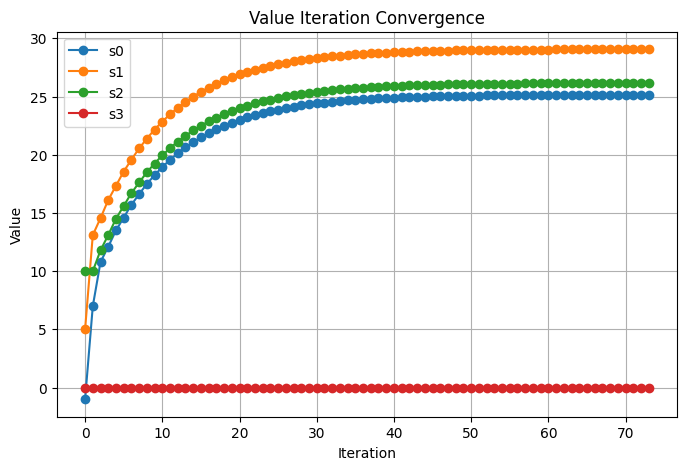

In [81]:
history = np.array(value_history)

plt.figure(figsize=(8,5))

for s in range(mdp.n_states):
    plt.plot(
        history[:, s],
        marker='o',
        label=mdp.states[s].name
    )

plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Value Iteration Convergence")
plt.grid(True)
plt.legend()


Both Policy Iteration and Value Iteration converged to the same optimal policy for the given MDP, confirming the correctness of the implementation.
Policy Iteration alternates between evaluating the current policy and improving it, while Value Iteration directly applies the Bellman Optimality Equation to update state values. 
For this small four-state MDP:
- both methods converged quickly and produced identical optimal actions and state values. 
- Policy Iteration may converge in fewer improvement steps, whereas Value Iteration typically performs simpler updates but may require more iterations to reach the convergence threshold.